In [31]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/motion_CNN
    filepath = "/content/drive/MyDrive/NUIN/mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat" 
    !git pull
else: 
  filepath =  "mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat"
    

In [32]:
from utilities import CorrelationVelDataset, show_batch_frames, show_one_sample_summary, sample_animation, split_by_source_image, prerender_dataset_to_single_pt, TensorMovieDataset
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import Subset, DataLoader
import os 
import numpy as np
import matplotlib.pyplot as plt

# Set the resolution for figures displayed in the notebook
plt.rcParams['figure.dpi'] = 100


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())

Using device: cpu
/home/guardomayas/NUIN/motion_detection


In [34]:
dataset = CorrelationVelDataset(
    file = filepath,
    crop_hw=(400,400),
    downsample_hw=(50,50),
    frames_per_segment=75,
    fps = 75,
    samples_per_image= 6, 
    vel_std = (350,350),
    vel_corr=-0.0
    )

print("dataset length:", len(dataset))

dataset length: 1950


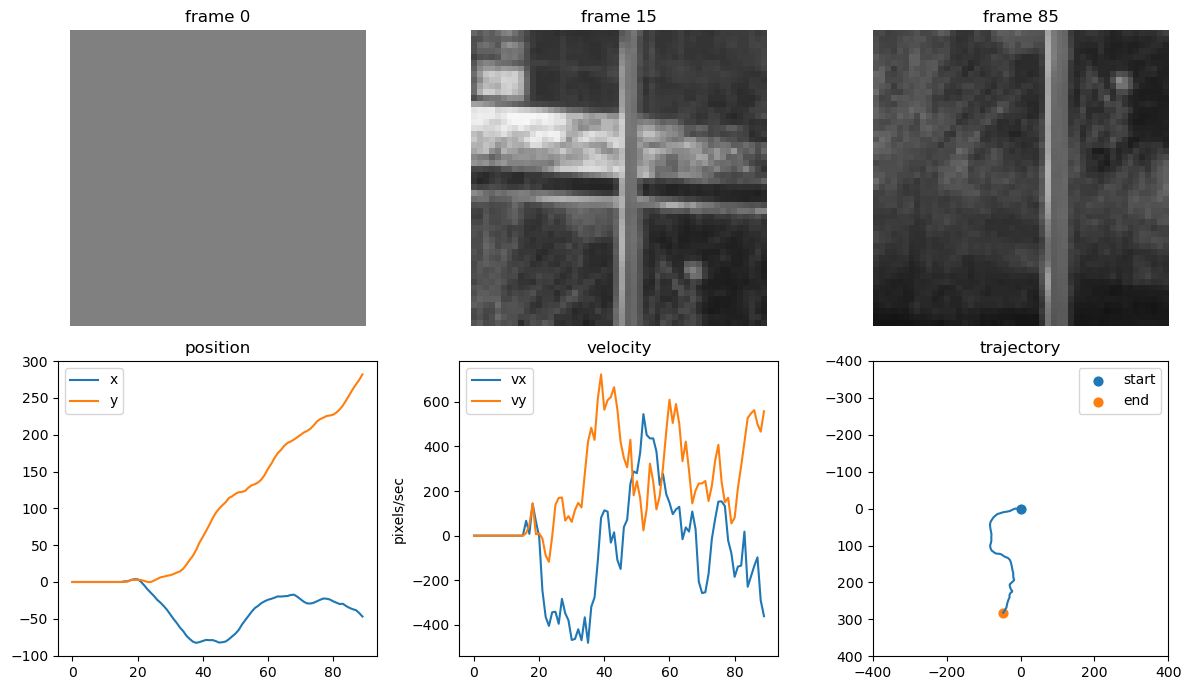

In [35]:
show_one_sample_summary(dataset, 0, frame_indices=[0,15,85])

In [36]:

# anim = sample_animation(dataset, 0, viz_fps=20, save_path=None)
# display(HTML(anim.to_jshtml()))

# Split/Val sets

In [37]:

train_dataset, val_dataset, train_keys, val_keys = split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
)
print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

print("Train images:", len(train_keys))
print("Val images:", len(val_keys))

print("Overlap:", len(train_keys & val_keys))

Total samples: 1950
Train samples: 1560
Val samples: 390
Train images: 260
Val images: 65
Overlap: 0


In [38]:
cache_name_train = (
    f"corrvel_train_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

cache_name_val = (
    f"corrvel_val_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

train_cache = prerender_dataset_to_single_pt(
    dataset,
    train_dataset.indices,
    f"cache/{cache_name_train}",
    movie_dtype=torch.float16,
    overwrite=False,
)

val_cache = prerender_dataset_to_single_pt(
    dataset,
    val_dataset.indices,
    f"cache/{cache_name_val}",
    movie_dtype=torch.float16,
    overwrite=False,
)

Cache already exists, skipping render: cache/corrvel_train_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt
Cache already exists, skipping render: cache/corrvel_val_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt


In [39]:
cached_train = TensorMovieDataset(f"cache/{cache_name_train}", movie_dtype=torch.float32)
cached_val = TensorMovieDataset(f"cache/{cache_name_val}", movie_dtype=torch.float32)

train_loader = DataLoader(
    cached_train,
    batch_size=16,
    shuffle=True,
    num_workers=0,   # try 0 first; increase later
    pin_memory=True,
)

val_loader = DataLoader(
    cached_val,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

## Fly-like CNN architecture

| Stage | Biological analogue | Computation | Output |
|---|---|---|---|
| Raw luminance movie | Visual input | Movie stimulus | \((B, T, 1, H, W)\) |
| Local contrast / preprocessing layer | Photoreceptors, lamina, bipolar-like preprocessing | DoG spatial filtering + biphasic temporal filtering | \((B, $C_{\text{pre}}$, T, H, W)\). Use \($C_{\text{pre}}$ = 2\) to enforce ON/OFF splitting |
| Spatiotemporal filter bank | Mi/Tm feature channels | Separable temporal/spatial filters | \((B, $C_{\text{ST}}$, T, H, W)\) |
| Local motion detector layer | T4/T5-like EMDs | Local spatiotemporal Conv3D producing direction channels | \((B, $C_{\text{dir}}$, T, H, W)\) |
| Widefield pooling layer | LPTCs / widefield motion cells | Spatial average pooling or learned weighted pooling | \((B, T, $C_{\text{dir}}$)\) or \((B, T, $C_{\text{wide}}$)\) |
| Velocity decoder | Downstream readout | Linear or shallow nonlinear decoder | \((B, T, 2)\) for \((v_x, v_y)\) |

```python
    class FlyLikeMotionCNN(nn.Module):
    def __init__(...):
        self.preprocess = ...
        self.st_bank = ...
        self.local_motion = ...
        self.widefield = ...
        self.decoder = ...
```

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoGSpatialFilter(nn.Module):
    """
    Constrained spatial Difference-of-Gaussians filter bank.

    ON/OFF-like identity lives here through a learned signed spatial amplitude.
    The spatial filter is always DoG-shaped, but its sign is learnable.

    Produces filters:
        weight: (out_channels, in_channels, kH, kW)
    """

    def __init__(
        self,
        in_channels=1,
        out_channels=4,
        kernel_size=11,
        init_sigma_center=1.2,
        init_sigma_ratio=2.5,
        init_eta=1.0,
        signed_amp_init=0.25,
        jitter=0.15,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size

        # Slight jitter so all channels do not start identical.
        sigma_c_init = init_sigma_center * torch.exp(
            jitter * torch.randn(out_channels, 1, 1, 1)
        )
        self.log_sigma_center = nn.Parameter(torch.log(sigma_c_init))

        # Surround sigma = sigma_center + softplus(delta_sigma)
        init_delta = init_sigma_center * (init_sigma_ratio - 1.0)
        raw_delta_init = torch.log(torch.exp(torch.tensor(float(init_delta))) - 1.0)
        self.raw_delta_sigma = nn.Parameter(
            raw_delta_init + jitter * torch.randn(out_channels, 1, 1, 1)
        )

        # Surround strength eta.
        eta_init = init_eta * torch.exp(
            0.10 * torch.randn(out_channels, 1, 1, 1)
        )
        self.log_eta = nn.Parameter(torch.log(eta_init))

        # Learned signed amplitude.
        # This is where ON/OFF-like polarity lives.
        sign = torch.sign(torch.randn(out_channels, 1, 1, 1))
        sign[sign == 0] = 1.0
        amp = signed_amp_init * sign * torch.exp(
            0.05 * torch.randn(out_channels, 1, 1, 1)
        )
        self.signed_amp = nn.Parameter(amp)

        # Coordinate grid.
        k = kernel_size
        y = torch.arange(k) - (k - 1) / 2
        x = torch.arange(k) - (k - 1) / 2
        yy, xx = torch.meshgrid(y, x, indexing="ij")
        r2 = xx**2 + yy**2
        self.register_buffer("r2", r2.view(1, 1, k, k))

    def get_weight(self):
        """
        Returns:
            weight: (out_channels, in_channels, kH, kW)
        """
        sigma_c = torch.exp(self.log_sigma_center)
        sigma_s = sigma_c + F.softplus(self.raw_delta_sigma)
        eta = torch.exp(self.log_eta)

        center = torch.exp(-self.r2 / (2 * sigma_c**2))
        surround = torch.exp(-self.r2 / (2 * sigma_s**2))

        # Area-normalize each Gaussian.
        center = center / (center.sum(dim=(-1, -2), keepdim=True) + 1e-8)
        surround = surround / (surround.sum(dim=(-1, -2), keepdim=True) + 1e-8)

        dog = center - eta * surround

        # Force contrast-like zero-mean spatial filters.
        dog = dog - dog.mean(dim=(-1, -2), keepdim=True)

        # Normalize DoG shape. signed_amp controls amplitude/sign.
        dog = dog / (dog.norm(dim=(-1, -2), keepdim=True) + 1e-8)

        weight = self.signed_amp * dog

        # Repeat across input channels if needed.
        weight = weight.repeat(1, self.in_channels, 1, 1)

        return weight

    def forward(self, x):
        """
        x: (B*T, C, H, W)
        returns: (B*T, out_channels, H, W)
        """
        weight = self.get_weight()
        return F.conv2d(
            x,
            weight,
            bias=None,
            padding=self.kernel_size // 2,
        )


class GammaDiffTemporalFilter(nn.Module):
    """
    Constrained gamma-difference temporal filter bank.

    Sign convention:
        - Temporal polarity is fixed.
        - Fast lobe amplitude is positive.
        - Slow lobe amplitude is negative.
        - tau_slow > tau_fast.

    Therefore, ON/OFF-like identity cannot be absorbed by flipping the temporal
    kernel. It must live in the spatial signed_amp.

    Input:
        x: (BHW, C, T)

    Output:
        y: (BHW, C, T)
    """

    def __init__(
        self,
        channels,
        frames=31,
        individual_shapes=True,
        temporal_causal=True,
        normalize=True,
        eps=1e-6,
    ):
        super().__init__()

        self.channels = channels
        self.frames = frames
        self.individual_shapes = individual_shapes
        self.temporal_causal = temporal_causal
        self.normalize = normalize
        self.eps = eps

        # Same scale as reference model.
        # Tau is measured in frames, not ms.
        self.max_tau = (frames - 1) / 3.0

        shape = (channels, 1, 1) if individual_shapes else (1, 1, 1)

        # Reference-style initialization:
        # scale1 ≈ +1.1, scale2 ≈ -0.95.
        self.raw_scale1 = nn.Parameter(
            torch.log(torch.exp(torch.tensor(1.1)) - 1.0)
            + 0.02 * torch.randn(shape)
        )

        self.raw_scale2_mag = nn.Parameter(
            torch.log(torch.exp(torch.tensor(0.95)) - 1.0)
            + 0.02 * torch.randn(shape)
        )

        # Reference-style tau initialization:
        # logit_tau1 ≈ 1.1
        # logit_tau2 ≈ 1.1 * 1.25
        #
        # But we parameterize as tau_slow = tau_fast + softplus(delta)
        # to enforce tau_slow > tau_fast.
        self.logit_tau_fast = nn.Parameter(
            0.02 * torch.randn(shape) + 1.1
        )

        # Initialize delta so slow tau starts slightly larger than fast tau.
        self.raw_delta_tau = nn.Parameter(
            0.02 * torch.randn(shape) + 0.5
        )

        self.nf1 = 6
        self.nf2 = 6

    def get_weight(self):
        """
        Returns:
            filt: (channels, 1, frames)
        """
        device = self.raw_scale1.device
        dtype = self.raw_scale1.dtype

        timepts = torch.arange(
            self.frames,
            device=device,
            dtype=dtype,
        ).view(1, 1, self.frames)

        # Positive fast lobe, negative slow lobe.
        scale1 = F.softplus(self.raw_scale1) + self.eps
        scale2 = -(F.softplus(self.raw_scale2_mag) + self.eps)

        tau_fast = self.max_tau * torch.sigmoid(self.logit_tau_fast)
        tau_fast = tau_fast + self.eps

        delta_tau = F.softplus(self.raw_delta_tau) + self.eps
        tau_slow = tau_fast + delta_tau

        t1 = timepts / tau_fast
        t2 = timepts / tau_slow

        filter1 = scale1 * t1**self.nf1 * torch.exp(
            -self.nf1 * (t1 - 1.0)
        )

        filter2 = scale2 * t2**self.nf2 * torch.exp(
            -self.nf2 * (t2 - 1.0)
        )

        filt = filter1 + filter2

        # Match causal Conv1d convention:
        # after padding on the left, the last kernel index corresponds
        # most closely to the present.
        filt = torch.flip(filt, dims=(-1,))

        if not self.individual_shapes:
            filt = filt.expand(self.channels, -1, -1)

        if self.normalize:
            # Temporal contrast/change-like filter.
            filt = filt - filt.mean(dim=-1, keepdim=True)

            # Normalize energy without allowing global sign flips.
            filt = filt / (filt.norm(dim=-1, keepdim=True) + 1e-8)

        return filt

    def forward(self, x):
        """
        x: (BHW, C, T)
        returns: (BHW, C, T)
        """
        weight = self.get_weight()

        if self.temporal_causal:
            x = F.pad(x, (self.frames - 1, 0))
        else:
            left = self.frames // 2
            right = self.frames - 1 - left
            x = F.pad(x, (left, right))

        return F.conv1d(x, weight, groups=self.channels)


class ConstrainedLocalContrastPreprocess(nn.Module):
    """
    Raw luminance -> local contrast channels using:

        constrained spatial DoG
        +
        constrained gamma-difference temporal filter

    Key convention:
        ON/OFF-like polarity belongs only to the spatial DoG signed amplitude.
        The temporal kernel has fixed orientation:
            positive fast lobe + negative slow lobe.

    Input:
        movie: (B, T, 1, H, W)

    Output:
        x: (B, C_pre, T, H, W)
    """

    def __init__(
        self,
        in_channels=1,
        out_channels=4,
        spatial_kernel=11,
        temporal_kernel=31,
        temporal_causal=True,
        learnable=True,
        init_sigma_center=1.2,
        init_sigma_ratio=2.5,
        init_eta=1.0,
        signed_amp_init=0.25,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.spatial_kernel = spatial_kernel
        self.temporal_kernel = temporal_kernel
        self.temporal_causal = temporal_causal

        self.spatial_dog = DoGSpatialFilter(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=spatial_kernel,
            init_sigma_center=init_sigma_center,
            init_sigma_ratio=init_sigma_ratio,
            init_eta=init_eta,
            signed_amp_init=signed_amp_init,
        )

        self.temporal_diff = GammaDiffTemporalFilter(
            channels=out_channels,
            frames=temporal_kernel,
            individual_shapes=True,
            temporal_causal=temporal_causal,
            normalize=True,
        )

        if not learnable:
            for p in self.parameters():
                p.requires_grad_(False)

    def forward(self, movie):
        """
        movie: (B, T, C, H, W)
        returns: (B, C_pre, T, H, W)
        """
        B, T, C, H, W = movie.shape

        # Spatial DoG filtering per frame.
        x = movie.reshape(B * T, C, H, W)
        x = self.spatial_dog(x)

        _, C_pre, H, W = x.shape
        x = x.reshape(B, T, C_pre, H, W)

        # Temporal filtering per channel at each pixel.
        x = x.permute(0, 3, 4, 2, 1)          # (B, H, W, C_pre, T)
        x = x.reshape(B * H * W, C_pre, T)    # (BHW, C_pre, T)

        x = self.temporal_diff(x)

        x = x.reshape(B, H, W, C_pre, T)
        x = x.permute(0, 3, 4, 1, 2)          # (B, C_pre, T, H, W)

        return x

    def get_spatial_filters(self, detach=True):
        weight = self.spatial_dog.get_weight()
        return weight.detach() if detach else weight

    def get_temporal_filters(self, detach=True):
        weight = self.temporal_diff.get_weight()
        return weight.detach() if detach else weight

    def get_filter_params(self):
        """
        Useful for inspecting learned preprocessing parameters.
        """
        with torch.no_grad():
            sigma_c = torch.exp(self.spatial_dog.log_sigma_center).flatten()
            sigma_s = (
                torch.exp(self.spatial_dog.log_sigma_center)
                + F.softplus(self.spatial_dog.raw_delta_sigma)
            ).flatten()
            eta = torch.exp(self.spatial_dog.log_eta).flatten()
            signed_amp = self.spatial_dog.signed_amp.flatten()

            scale1 = (
                F.softplus(self.temporal_diff.raw_scale1)
                + self.temporal_diff.eps
            ).flatten()

            scale2 = -(
                F.softplus(self.temporal_diff.raw_scale2_mag)
                + self.temporal_diff.eps
            ).flatten()

            tau_fast = (
                self.temporal_diff.max_tau
                * torch.sigmoid(self.temporal_diff.logit_tau_fast)
                + self.temporal_diff.eps
            ).flatten()

            tau_slow = (
                self.temporal_diff.max_tau
                * torch.sigmoid(self.temporal_diff.logit_tau_fast)
                + self.temporal_diff.eps
                + F.softplus(self.temporal_diff.raw_delta_tau)
                + self.temporal_diff.eps
            ).flatten()

        return {
            "sigma_center_px": sigma_c,
            "sigma_surround_px": sigma_s,
            "eta": eta,
            "spatial_signed_amp": signed_amp,
            "temporal_scale_fast_positive": scale1,
            "temporal_scale_slow_negative": scale2,
            "tau_fast_frames": tau_fast,
            "tau_slow_frames": tau_slow,
        }

In [41]:
torch.manual_seed(0)


preprocess = ConstrainedLocalContrastPreprocess(
    in_channels=1,
    out_channels=4,
    spatial_kernel=11,
    temporal_kernel=31,
    temporal_causal=True,
    learnable=True,
)


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F


class DoGSpatialFilter(nn.Module):
    """
    Constrained spatial Difference-of-Gaussians filter bank.

    ON/OFF-like identity lives here through a learned signed spatial amplitude.
    The spatial filter is always DoG-shaped, but its sign is learnable.

    Produces filters:
        weight: (out_channels, in_channels, kH, kW)
    """

    def __init__(
        self,
        in_channels=1,
        out_channels=4,
        kernel_size=11,
        init_sigma_center=1.2,
        init_sigma_ratio=2.5,
        init_eta=1.0,
        signed_amp_init=0.25,
        jitter=0.15,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size

        # Slight jitter so all channels do not start identical.
        sigma_c_init = init_sigma_center * torch.exp(
            jitter * torch.randn(out_channels, 1, 1, 1)
        )
        self.log_sigma_center = nn.Parameter(torch.log(sigma_c_init))

        # Surround sigma = sigma_center + softplus(delta_sigma)
        init_delta = init_sigma_center * (init_sigma_ratio - 1.0)
        raw_delta_init = torch.log(torch.exp(torch.tensor(float(init_delta))) - 1.0)
        self.raw_delta_sigma = nn.Parameter(
            raw_delta_init + jitter * torch.randn(out_channels, 1, 1, 1)
        )

        # Surround strength eta.
        eta_init = init_eta * torch.exp(
            0.10 * torch.randn(out_channels, 1, 1, 1)
        )
        self.log_eta = nn.Parameter(torch.log(eta_init))

        # Learned signed amplitude.
        # This is where ON/OFF-like polarity lives.
        sign = torch.sign(torch.randn(out_channels, 1, 1, 1))
        sign[sign == 0] = 1.0
        amp = signed_amp_init * sign * torch.exp(
            0.05 * torch.randn(out_channels, 1, 1, 1)
        )
        self.signed_amp = nn.Parameter(amp)

        # Coordinate grid.
        k = kernel_size
        y = torch.arange(k) - (k - 1) / 2
        x = torch.arange(k) - (k - 1) / 2
        yy, xx = torch.meshgrid(y, x, indexing="ij")
        r2 = xx**2 + yy**2
        self.register_buffer("r2", r2.view(1, 1, k, k))

    def get_weight(self):
        """
        Returns:
            weight: (out_channels, in_channels, kH, kW)
        """
        sigma_c = torch.exp(self.log_sigma_center)
        sigma_s = sigma_c + F.softplus(self.raw_delta_sigma)
        eta = torch.exp(self.log_eta)

        center = torch.exp(-self.r2 / (2 * sigma_c**2))
        surround = torch.exp(-self.r2 / (2 * sigma_s**2))

        # Area-normalize each Gaussian.
        center = center / (center.sum(dim=(-1, -2), keepdim=True) + 1e-8)
        surround = surround / (surround.sum(dim=(-1, -2), keepdim=True) + 1e-8)

        dog = center - eta * surround

        # Force contrast-like zero-mean spatial filters.
        dog = dog - dog.mean(dim=(-1, -2), keepdim=True)

        # Normalize DoG shape. signed_amp controls amplitude/sign.
        dog = dog / (dog.norm(dim=(-1, -2), keepdim=True) + 1e-8)

        weight = self.signed_amp * dog

        # Repeat across input channels if needed.
        weight = weight.repeat(1, self.in_channels, 1, 1)

        return weight

    def forward(self, x):
        """
        x: (B*T, C, H, W)
        returns: (B*T, out_channels, H, W)
        """
        weight = self.get_weight()
        return F.conv2d(
            x,
            weight,
            bias=None,
            padding=self.kernel_size // 2,
        )


class GammaDiffTemporalFilter(nn.Module):
    """
    Constrained gamma-difference temporal filter bank.

    Sign convention:
        - Temporal polarity is fixed.
        - Fast lobe amplitude is positive.
        - Slow lobe amplitude is negative.
        - tau_slow > tau_fast.

    Therefore, ON/OFF-like identity cannot be absorbed by flipping the temporal
    kernel. It must live in the spatial signed_amp.

    Input:
        x: (BHW, C, T)

    Output:
        y: (BHW, C, T)
    """

    def __init__(
        self,
        channels,
        frames=31,
        individual_shapes=True,
        temporal_causal=True,
        normalize=True,
        eps=1e-6,
    ):
        super().__init__()

        self.channels = channels
        self.frames = frames
        self.individual_shapes = individual_shapes
        self.temporal_causal = temporal_causal
        self.normalize = normalize
        self.eps = eps

        # Same scale as reference model.
        # Tau is measured in frames, not ms.
        self.max_tau = (frames - 1) / 3.0

        shape = (channels, 1, 1) if individual_shapes else (1, 1, 1)

        # Reference-style initialization:
        # scale1 ≈ +1.1, scale2 ≈ -0.95.
        self.raw_scale1 = nn.Parameter(
            torch.log(torch.exp(torch.tensor(1.1)) - 1.0)
            + 0.02 * torch.randn(shape)
        )

        self.raw_scale2_mag = nn.Parameter(
            torch.log(torch.exp(torch.tensor(0.95)) - 1.0)
            + 0.02 * torch.randn(shape)
        )

        # Reference-style tau initialization:
        # logit_tau1 ≈ 1.1
        # logit_tau2 ≈ 1.1 * 1.25
        #
        # But we parameterize as tau_slow = tau_fast + softplus(delta)
        # to enforce tau_slow > tau_fast.
        self.logit_tau_fast = nn.Parameter(
            0.02 * torch.randn(shape) + 1.1
        )

        # Initialize delta so slow tau starts slightly larger than fast tau.
        self.raw_delta_tau = nn.Parameter(
            0.02 * torch.randn(shape) + 0.5
        )

        self.nf1 = 6
        self.nf2 = 6

    def get_weight(self):
        """
        Returns:
            filt: (channels, 1, frames)
        """
        device = self.raw_scale1.device
        dtype = self.raw_scale1.dtype

        timepts = torch.arange(
            self.frames,
            device=device,
            dtype=dtype,
        ).view(1, 1, self.frames)

        # Positive fast lobe, negative slow lobe.
        scale1 = F.softplus(self.raw_scale1) + self.eps
        scale2 = -(F.softplus(self.raw_scale2_mag) + self.eps)

        tau_fast = self.max_tau * torch.sigmoid(self.logit_tau_fast)
        tau_fast = tau_fast + self.eps

        delta_tau = F.softplus(self.raw_delta_tau) + self.eps
        tau_slow = tau_fast + delta_tau

        t1 = timepts / tau_fast
        t2 = timepts / tau_slow

        filter1 = scale1 * t1**self.nf1 * torch.exp(
            -self.nf1 * (t1 - 1.0)
        )

        filter2 = scale2 * t2**self.nf2 * torch.exp(
            -self.nf2 * (t2 - 1.0)
        )

        filt = filter1 + filter2

        # Match causal Conv1d convention:
        # after padding on the left, the last kernel index corresponds
        # most closely to the present.
        filt = torch.flip(filt, dims=(-1,))

        if not self.individual_shapes:
            filt = filt.expand(self.channels, -1, -1)

        if self.normalize:
            # Temporal contrast/change-like filter.
            filt = filt - filt.mean(dim=-1, keepdim=True)

            # Normalize energy without allowing global sign flips.
            filt = filt / (filt.norm(dim=-1, keepdim=True) + 1e-8)

        return filt

    def forward(self, x):
        """
        x: (BHW, C, T)
        returns: (BHW, C, T)
        """
        weight = self.get_weight()

        if self.temporal_causal:
            x = F.pad(x, (self.frames - 1, 0))
        else:
            left = self.frames // 2
            right = self.frames - 1 - left
            x = F.pad(x, (left, right))

        return F.conv1d(x, weight, groups=self.channels)


class ConstrainedLocalContrastPreprocess(nn.Module):
    """
    Raw luminance -> local contrast channels using:

        constrained spatial DoG
        +
        constrained gamma-difference temporal filter

    Key convention:
        ON/OFF-like polarity belongs only to the spatial DoG signed amplitude.
        The temporal kernel has fixed orientation:
            positive fast lobe + negative slow lobe.

    Input:
        movie: (B, T, 1, H, W)

    Output:
        x: (B, C_pre, T, H, W)
    """

    def __init__(
        self,
        in_channels=1,
        out_channels=4,
        spatial_kernel=11,
        temporal_kernel=31,
        temporal_causal=True,
        learnable=True,
        init_sigma_center=1.2,
        init_sigma_ratio=2.5,
        init_eta=1.0,
        signed_amp_init=0.25,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.spatial_kernel = spatial_kernel
        self.temporal_kernel = temporal_kernel
        self.temporal_causal = temporal_causal

        self.spatial_dog = DoGSpatialFilter(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=spatial_kernel,
            init_sigma_center=init_sigma_center,
            init_sigma_ratio=init_sigma_ratio,
            init_eta=init_eta,
            signed_amp_init=signed_amp_init,
        )

        self.temporal_diff = GammaDiffTemporalFilter(
            channels=out_channels,
            frames=temporal_kernel,
            individual_shapes=True,
            temporal_causal=temporal_causal,
            normalize=True,
        )

        if not learnable:
            for p in self.parameters():
                p.requires_grad_(False)

    def forward(self, movie):
        """
        movie: (B, T, C, H, W)
        returns: (B, C_pre, T, H, W)
        """
        B, T, C, H, W = movie.shape

        # Spatial DoG filtering per frame.
        x = movie.reshape(B * T, C, H, W)
        x = self.spatial_dog(x)

        _, C_pre, H, W = x.shape
        x = x.reshape(B, T, C_pre, H, W)

        # Temporal filtering per channel at each pixel.
        x = x.permute(0, 3, 4, 2, 1)          # (B, H, W, C_pre, T)
        x = x.reshape(B * H * W, C_pre, T)    # (BHW, C_pre, T)

        x = self.temporal_diff(x)

        x = x.reshape(B, H, W, C_pre, T)
        x = x.permute(0, 3, 4, 1, 2)          # (B, C_pre, T, H, W)

        return x

    def get_spatial_filters(self, detach=True):
        weight = self.spatial_dog.get_weight()
        return weight.detach() if detach else weight

    def get_temporal_filters(self, detach=True):
        weight = self.temporal_diff.get_weight()
        return weight.detach() if detach else weight

    def get_filter_params(self):
        """
        Useful for inspecting learned preprocessing parameters.
        """
        with torch.no_grad():
            sigma_c = torch.exp(self.spatial_dog.log_sigma_center).flatten()
            sigma_s = (
                torch.exp(self.spatial_dog.log_sigma_center)
                + F.softplus(self.spatial_dog.raw_delta_sigma)
            ).flatten()
            eta = torch.exp(self.spatial_dog.log_eta).flatten()
            signed_amp = self.spatial_dog.signed_amp.flatten()

            scale1 = (
                F.softplus(self.temporal_diff.raw_scale1)
                + self.temporal_diff.eps
            ).flatten()

            scale2 = -(
                F.softplus(self.temporal_diff.raw_scale2_mag)
                + self.temporal_diff.eps
            ).flatten()

            tau_fast = (
                self.temporal_diff.max_tau
                * torch.sigmoid(self.temporal_diff.logit_tau_fast)
                + self.temporal_diff.eps
            ).flatten()

            tau_slow = (
                self.temporal_diff.max_tau
                * torch.sigmoid(self.temporal_diff.logit_tau_fast)
                + self.temporal_diff.eps
                + F.softplus(self.temporal_diff.raw_delta_tau)
                + self.temporal_diff.eps
            ).flatten()

        return {
            "sigma_center_px": sigma_c,
            "sigma_surround_px": sigma_s,
            "eta": eta,
            "spatial_signed_amp": signed_amp,
            "temporal_scale_fast_positive": scale1,
            "temporal_scale_slow_negative": scale2,
            "tau_fast_frames": tau_fast,
            "tau_slow_frames": tau_slow,
        }

In [44]:
import numpy as np
import matplotlib.pyplot as plt


def plot_constrained_preprocess_filters(
    preprocess,
    fps=75,
    embed_canvas_hw=None,
):
    """
    Plot:
      1. spatial DoG filters
      2. optional spatial filters embedded in a larger movie-sized canvas
      3. temporal gamma-difference filters

    Parameters
    ----------
    preprocess : ConstrainedLocalContrastPreprocess
    fps : float
        Movie frame rate. Used only for plotting temporal axis in ms.
    embed_canvas_hw : tuple or None
        Example: (50, 50). If provided, plots each small spatial kernel
        centered inside a larger blank image canvas.
    """
    spatial = preprocess.get_spatial_filters().detach().cpu().numpy()
    temporal = preprocess.get_temporal_filters().detach().cpu().numpy()

    C_pre = spatial.shape[0]
    K = temporal.shape[-1]

    dt_ms = 1000 / fps
    time_ms = -(K - 1 - np.arange(K)) * dt_ms

    ncols = 3 if embed_canvas_hw is not None else 2

    fig, axes = plt.subplots(
        C_pre,
        ncols,
        figsize=(4.4 * ncols, 2.8 * C_pre),
        constrained_layout=True,
    )

    if C_pre == 1:
        axes = np.array([axes])

    for c in range(C_pre):
        # Spatial DoG kernel.
        ax = axes[c, 0]
        filt = spatial[c, 0]

        vmax = np.max(np.abs(filt)) + 1e-8
        im = ax.imshow(filt, cmap="coolwarm", vmin=-vmax, vmax=vmax)
        ax.set_title(f"Spatial DoG ch {c}")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Optional embedded view.
        if embed_canvas_hw is not None:
            ax = axes[c, 1]

            Hc, Wc = embed_canvas_hw
            kH, kW = filt.shape
            canvas = np.zeros((Hc, Wc), dtype=np.float32)

            cy, cx = Hc // 2, Wc // 2
            y0 = cy - kH // 2
            x0 = cx - kW // 2
            y1 = y0 + kH
            x1 = x0 + kW

            canvas[y0:y1, x0:x1] = filt

            vmax_canvas = np.max(np.abs(canvas)) + 1e-8
            im = ax.imshow(canvas, cmap="coolwarm", vmin=-vmax_canvas, vmax=vmax_canvas)
            ax.set_title(f"Embedded in {Hc}x{Wc} ch {c}")
            ax.set_xticks([])
            ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            temporal_col = 2
        else:
            temporal_col = 1

        # Temporal filter.
        ax = axes[c, temporal_col]
        temp = temporal[c, 0]

        ax.plot(time_ms, temp, marker="o", markersize=3)
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(f"Temporal gamma-diff ch {c}")
        ax.set_xlabel("Time before present (ms)")
        ax.set_ylabel("Weight")

    plt.show()

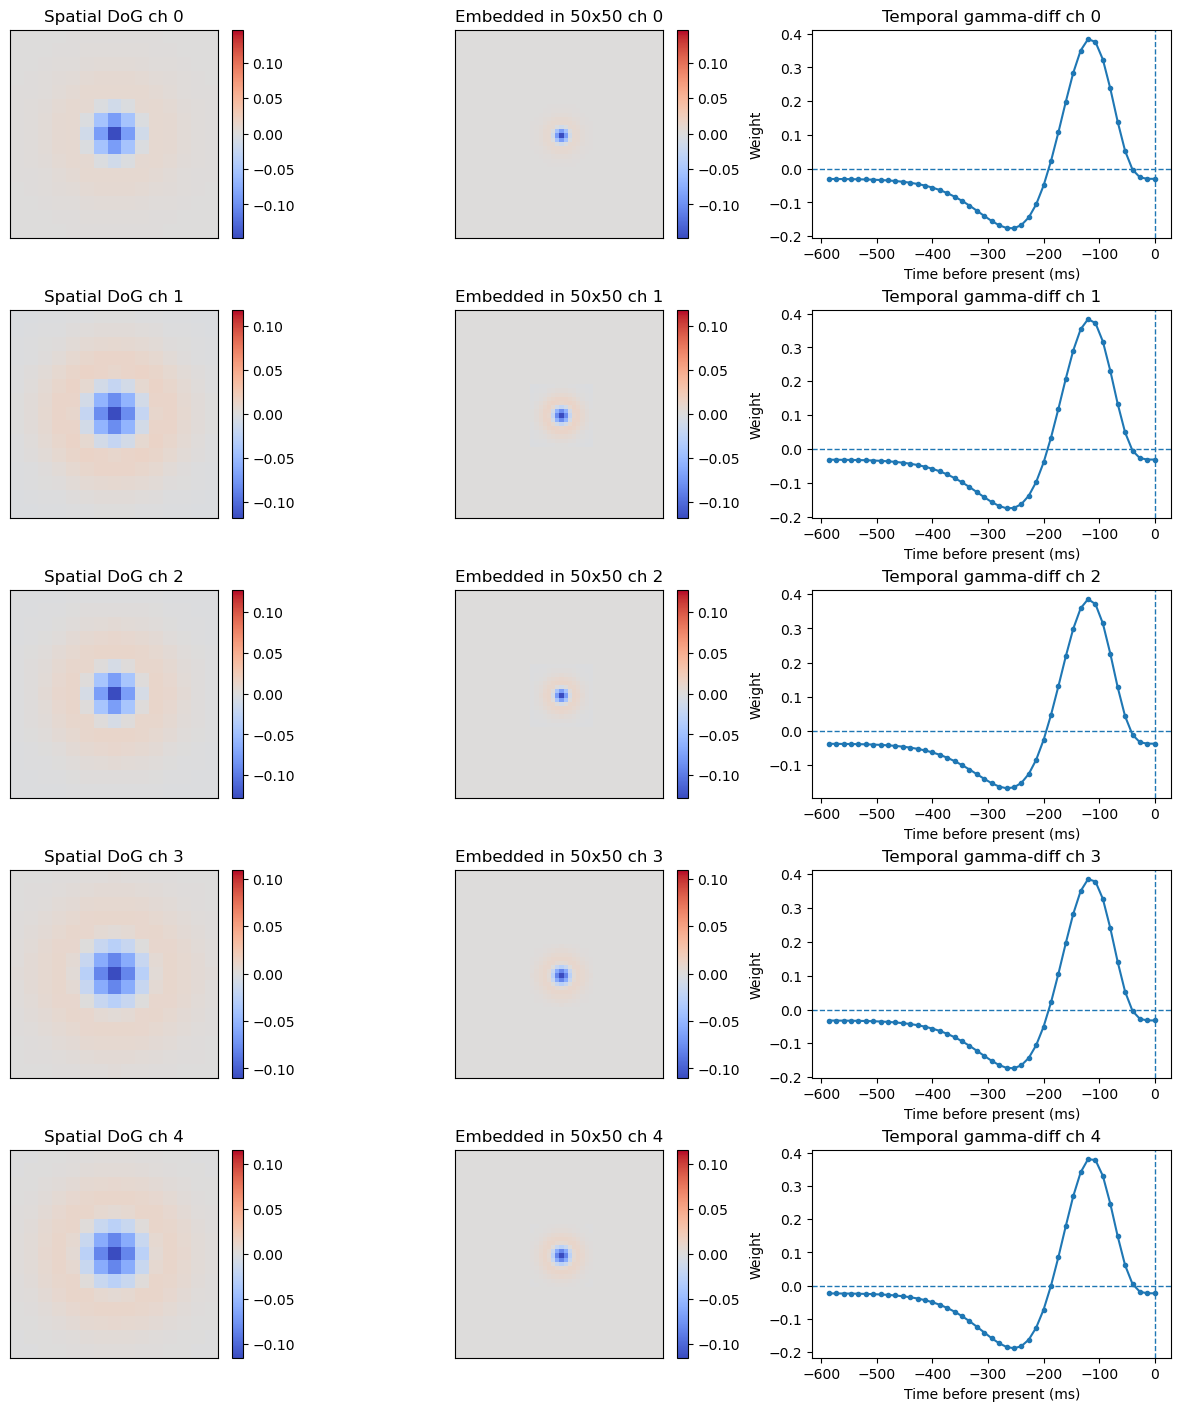

sigma_center_px [1.0794753 1.3276883 1.1057434 1.3756549 1.408536 ]
sigma_surround_px [2.897335  2.9706388 2.8836446 3.3034382 3.0290766]
eta [0.9115876 1.2865481 1.3343244 1.0009195 1.056414 ]
spatial_signed_amp [-0.26435605 -0.25149107 -0.23214388 -0.24707724 -0.26094717]
temporal_scale_fast_positive [1.0913705 1.1096648 1.1127543 1.1137773 1.0907147]
temporal_scale_slow_negative [-0.9439367  -0.95847005 -0.95191234 -0.956619   -0.9597232 ]
tau_fast_frames [10.987263 11.078802 11.076739 10.904791 10.948913]
tau_slow_frames [11.96824  12.063206 12.032696 11.888664 11.916595]


In [51]:
torch.manual_seed(15)

preprocess = ConstrainedLocalContrastPreprocess(
    in_channels=1,
    out_channels=5,
    spatial_kernel=15,
    temporal_kernel=45,
    temporal_causal=True,
    learnable=True,
)

plot_constrained_preprocess_filters(
    preprocess,
    fps=75,
    embed_canvas_hw=(50, 50),
)

params = preprocess.get_filter_params()
for k, v in params.items():
    print(k, v.detach().cpu().numpy())